# Newsroom — Analysis

Models:
- Mistral
- LLaMA
- GPT-4o

In [45]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
import pandas as pd
pd.set_option('display.max_columns', None) # display all columns

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [47]:
# Load preprocessed data (run preprocessing.ipynb first if needed)
df = pd.read_csv('../data/newsroom_judged_cleaned.csv')

print(f"Loaded cleaned dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded cleaned dataset shape: (327, 24)
Columns: ['GPT_informativeness_as_a_judge', 'GPT_relevance_as_a_judge', 'GPT_fluency_as_a_judge', 'GPT_coherence_as_a_judge', 'LLAMA_informativeness_as_a_judge', 'LLAMA_relevance_as_a_judge', 'LLAMA_fluency_as_a_judge', 'LLAMA_coherence_as_a_judge', 'MISTRAL_informativeness_as_a_judge', 'MISTRAL_relevance_as_a_judge', 'MISTRAL_fluency_as_a_judge', 'MISTRAL_coherence_as_a_judge', 'informativeness_human_#1', 'informativeness_human_#2', 'informativeness_human_#3', 'relevance_human_#1', 'relevance_human_#2', 'relevance_human_#3', 'fluency_human_#1', 'fluency_human_#2', 'fluency_human_#3', 'coherence_human_#1', 'coherence_human_#2', 'coherence_human_#3']


,GPT_informativeness_as_a_judge,GPT_relevance_as_a_judge,GPT_fluency_as_a_judge,GPT_coherence_as_a_judge,LLAMA_informativeness_as_a_judge,LLAMA_relevance_as_a_judge,LLAMA_fluency_as_a_judge,LLAMA_coherence_as_a_judge,MISTRAL_informativeness_as_a_judge,MISTRAL_relevance_as_a_judge,MISTRAL_fluency_as_a_judge,MISTRAL_coherence_as_a_judge,informativeness_human_#1,informativeness_human_#2,informativeness_human_#3,relevance_human_#1,relevance_human_#2,relevance_human_#3,fluency_human_#1,fluency_human_#2,fluency_human_#3,coherence_human_#1,coherence_human_#2,coherence_human_#3
0,1,1,1,1,2,2,1,2,4.0,1.0,2,1,3,1,1,4,1,1,5,3,1,5,1,1
1,1,1,1,1,2,2,2,3,4.0,3.0,4,3,3,1,4,4,2,3,4,3,3,4,1,4
2,1,1,2,1,2,2,2,2,5.0,5.0,4,4,2,1,5,2,5,4,3,5,5,2,2,5
3,1,1,2,1,2,2,2,3,3.0,4.0,3,2,5,2,4,4,4,4,5,4,2,5,4,3
4,1,1,1,1,1,1,1,1,1.0,1.0,4,2,5,3,4,4,2,3,5,2,4,5,2,5


In [48]:
# Define column groups and score range for analysis
MIN, MAX = 1, 5

# Human columns by metric
human_informative_cols = [col for col in df.columns if 'informativeness_human_' in col]
human_relevance_cols   = [col for col in df.columns if 'relevance_human_' in col]
human_fluency_cols     = [col for col in df.columns if 'fluency_human_' in col]
human_coherence_cols   = [col for col in df.columns if 'coherence_human_' in col]

# LLM columns by metric
llm_informative_cols = [col for col in df.columns if 'informativeness_as_a_judge' in col]
llm_relevance_cols   = [col for col in df.columns if 'relevance_as_a_judge' in col]
llm_fluency_cols     = [col for col in df.columns if 'fluency_as_a_judge' in col]
llm_coherence_cols   = [col for col in df.columns if 'coherence_as_a_judge' in col]

print(f"Score range: [{MIN}, {MAX}]")
print(f"\nHuman columns:")
print(f"  Informativeness: {human_informative_cols}")
print(f"  Relevance: {human_relevance_cols}")
print(f"  Fluency: {human_fluency_cols}")
print(f"  Coherence: {human_coherence_cols}")
print(f"\nLLM columns:")
print(f"  Informativeness: {llm_informative_cols}")
print(f"  Relevance: {llm_relevance_cols}")
print(f"  Fluency: {llm_fluency_cols}")
print(f"  Coherence: {llm_coherence_cols}")

Score range: [1, 5]

Human columns:
  Informativeness: ['informativeness_human_#1', 'informativeness_human_#2', 'informativeness_human_#3']
  Relevance: ['relevance_human_#1', 'relevance_human_#2', 'relevance_human_#3']
  Fluency: ['fluency_human_#1', 'fluency_human_#2', 'fluency_human_#3']
  Coherence: ['coherence_human_#1', 'coherence_human_#2', 'coherence_human_#3']

LLM columns:
  Informativeness: ['GPT_informativeness_as_a_judge', 'LLAMA_informativeness_as_a_judge', 'MISTRAL_informativeness_as_a_judge']
  Relevance: ['GPT_relevance_as_a_judge', 'LLAMA_relevance_as_a_judge', 'MISTRAL_relevance_as_a_judge']
  Fluency: ['GPT_fluency_as_a_judge', 'LLAMA_fluency_as_a_judge', 'MISTRAL_fluency_as_a_judge']
  Coherence: ['GPT_coherence_as_a_judge', 'LLAMA_coherence_as_a_judge', 'MISTRAL_coherence_as_a_judge']


## Diversity of opinion

In [49]:
# Fix import path - add parent directory to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))

from core.llm_good_enough import LLMGoodEnough

# Initialize evaluators for each metric
good_enough_informativeness = LLMGoodEnough(
    df=df,
    human_cols=human_informative_cols,
    llm_cols=llm_informative_cols,
    min_score=MIN,
    max_score=MAX,
    verbosity=0
)
good_enough_relevance = LLMGoodEnough(
    df=df,
    human_cols=human_relevance_cols,
    llm_cols=llm_relevance_cols,
    min_score=MIN,
    max_score=MAX,
    verbosity=0
)
good_enough_fluency = LLMGoodEnough(
    df=df,
    human_cols=human_fluency_cols,
    llm_cols=llm_fluency_cols,
    min_score=MIN,
    max_score=MAX,
    verbosity=0
)
good_enough_coherence = LLMGoodEnough(
    df=df,
    human_cols=human_coherence_cols,
    llm_cols=llm_coherence_cols,
    min_score=MIN,
    max_score=MAX,
    verbosity=0
)

### 1. Human-Human disagreement


In [50]:
human_disagreements = {
    'informativeness': good_enough_informativeness.compute_human_disagreements(),
    'relevance': good_enough_relevance.compute_human_disagreements(),
    'fluency': good_enough_fluency.compute_human_disagreements(),
    'coherence': good_enough_coherence.compute_human_disagreements()
}

# print mean and std for each array in human_disagreements
for metric, disagreements in human_disagreements.items():
    print(f"{metric}: mean={disagreements.mean():.2f}, std={disagreements.std():.2f}")

informativeness: mean=1.05, std=0.95
relevance: mean=1.15, std=1.05
fluency: mean=1.45, std=1.11
coherence: mean=1.32, std=1.07


In [51]:
human_disagreements_df = pd.DataFrame(human_disagreements)
print(human_disagreements_df.shape)
human_disagreements_df.head()

(981, 4)


,informativeness,relevance,fluency,coherence
0,2,3,2,4
1,2,3,4,4
2,0,0,2,0
3,2,2,1,3
4,1,1,1,0


### 2. LLM-Human disagreement

In [52]:
evaluators = {
    'informativeness_evaluator': good_enough_informativeness,
    'relevance_evaluator': good_enough_relevance,
    'fluency_evaluator': good_enough_fluency,
    'coherence_evaluator': good_enough_coherence
}

# as dict comprehension
llm_human_disagreements = {
    f'{model}_{metric}': evaluators[f'{metric}_evaluator'].compute_llm_human_disagreements(
        f'{model}_{metric}_as_a_judge'
    )
    for model in ['MISTRAL', 'LLAMA', 'GPT']
    for metric in ['informativeness', 'relevance', 'fluency', 'coherence']
}

# print mean and std for each array in llm_human_disagreements
for metric, disagreements in llm_human_disagreements.items():
    print(f"{metric}: mean={disagreements.mean():.2f}, std={disagreements.std():.2f}")

MISTRAL_informativeness: mean=0.99, std=1.00
MISTRAL_relevance: mean=1.02, std=1.03
MISTRAL_fluency: mean=1.26, std=1.15
MISTRAL_coherence: mean=1.24, std=1.10
LLAMA_informativeness: mean=1.57, std=1.05
LLAMA_relevance: mean=1.60, std=1.14
LLAMA_fluency: mean=1.48, std=1.19
LLAMA_coherence: mean=1.31, std=1.03
GPT_informativeness: mean=1.73, std=1.10
GPT_relevance: mean=1.60, std=1.21
GPT_fluency: mean=1.48, std=1.22
GPT_coherence: mean=1.68, std=1.22


In [53]:
llm_human_disagreements.keys()

dict_keys(['MISTRAL_informativeness', 'MISTRAL_relevance', 'MISTRAL_fluency', 'MISTRAL_coherence', 'LLAMA_informativeness', 'LLAMA_relevance', 'LLAMA_fluency', 'LLAMA_coherence', 'GPT_informativeness', 'GPT_relevance', 'GPT_fluency', 'GPT_coherence'])

### 3. Random-Human disagreement


In [54]:
# compute human-random judge disagreement
human_random_disagreements = {
    f'random_{metric}': evaluators[f'{metric}_evaluator'].compute_llm_human_disagreements(
        'RANDOM_as_a_judge'
    )
    for metric in ['informativeness', 'relevance', 'fluency', 'coherence']
}

In [55]:
human_random_disagreements.keys()

dict_keys(['random_informativeness', 'random_relevance', 'random_fluency', 'random_coherence'])

## Results

**Hypotheses (MWU, one-sided `alternative="greater"`):**
- **H₀:** LLM–Human disagreement is not greater than Human–Human disagreement.
- **H₁:** LLM–Human disagreement is greater.

### Informativeness

✅ Figure saved as PDF → ../figures/pdf/newsroom_informativeness_barplot.pdf


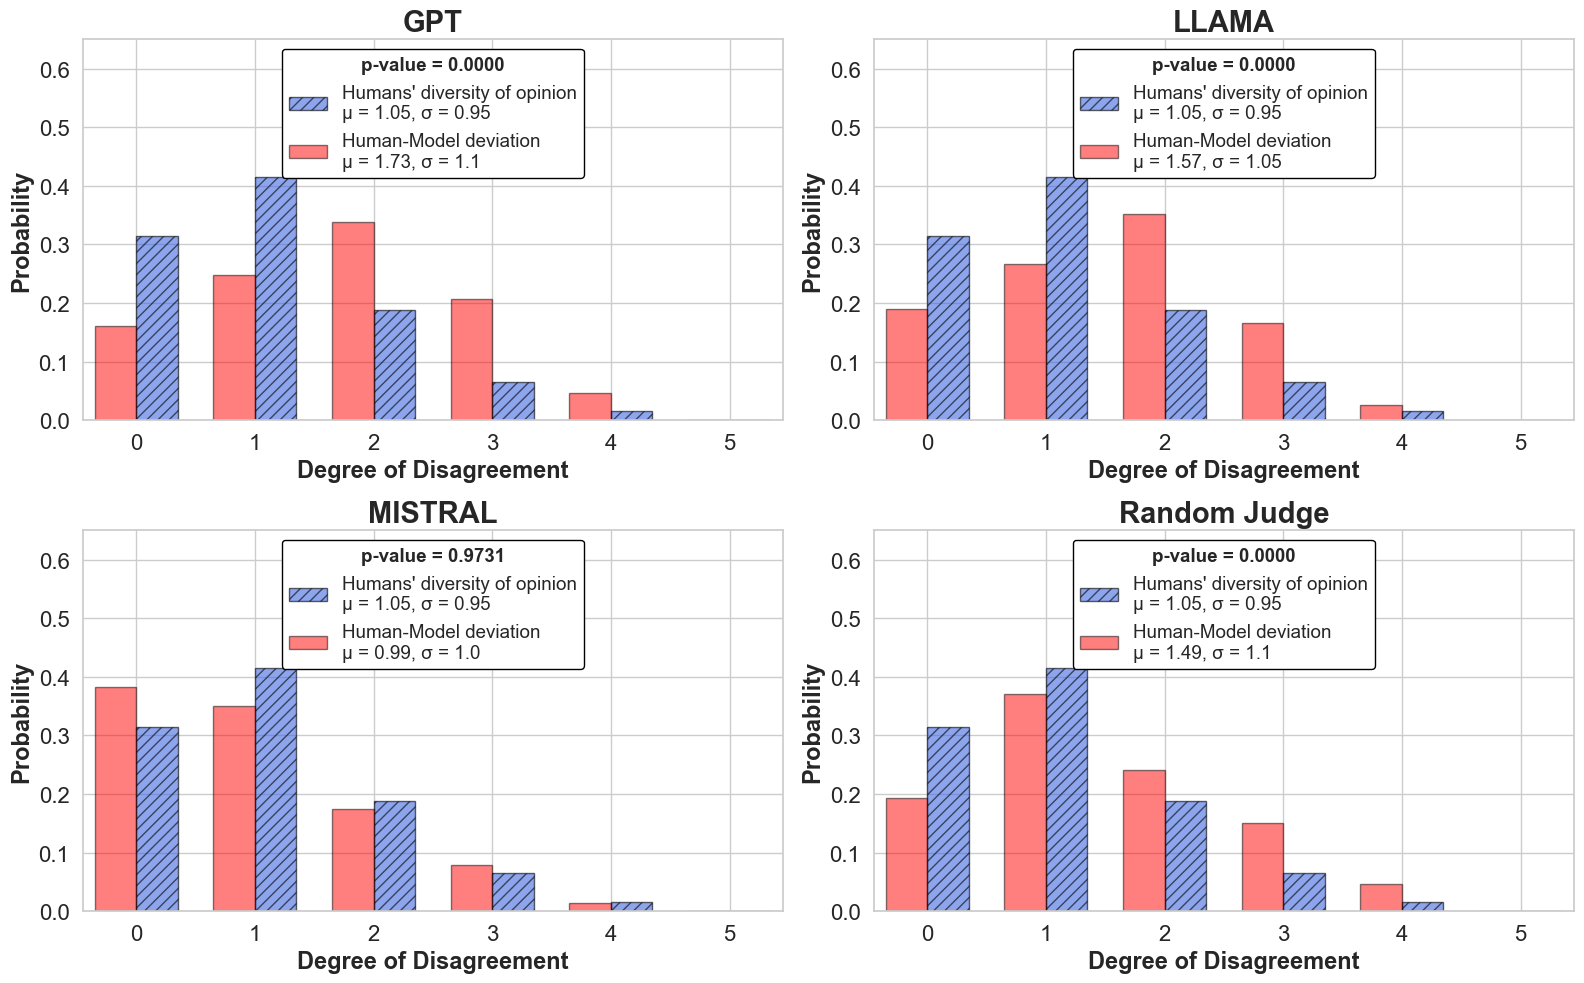

In [56]:
good_enough_informativeness.plot_judges_grid(
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.65,
    save_path="../figures/pdf/newsroom_informativeness_barplot.pdf"
)


### Relevance

✅ Figure saved as PDF → ../figures/pdf/newsroom_relevance.pdf


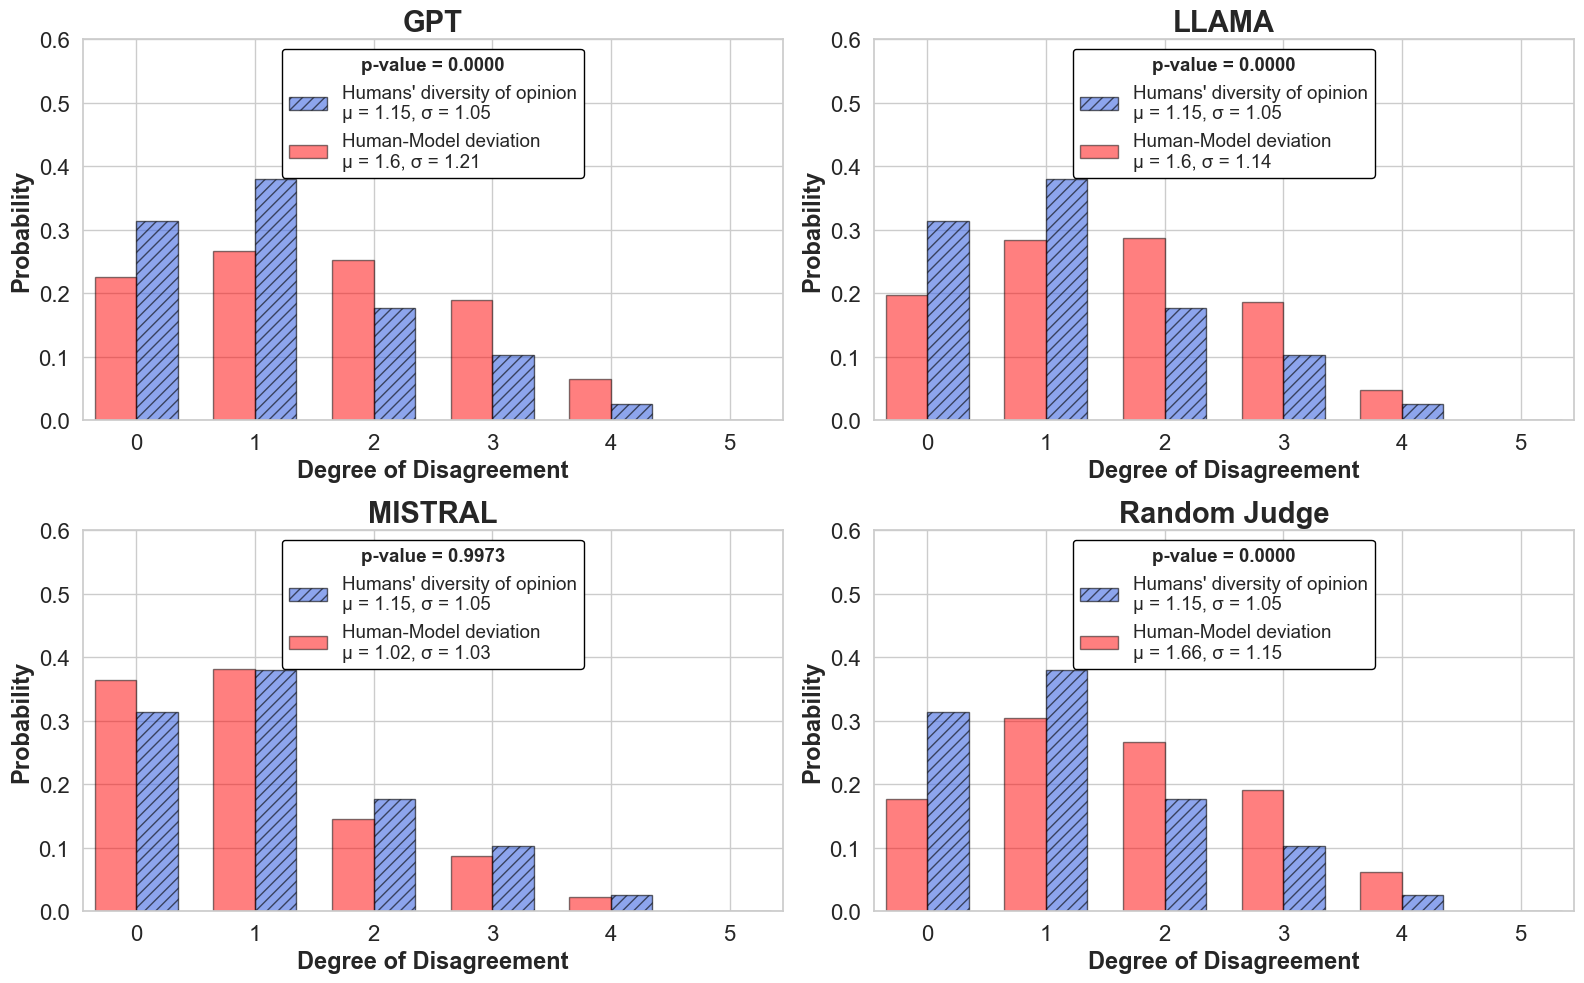

In [57]:
good_enough_relevance.plot_judges_grid(
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.6,
    save_path="../figures/pdf/newsroom_relevance.pdf"
)

### Fluency

✅ Figure saved as PDF → ../figures/pdf/newsroom_fluency.pdf


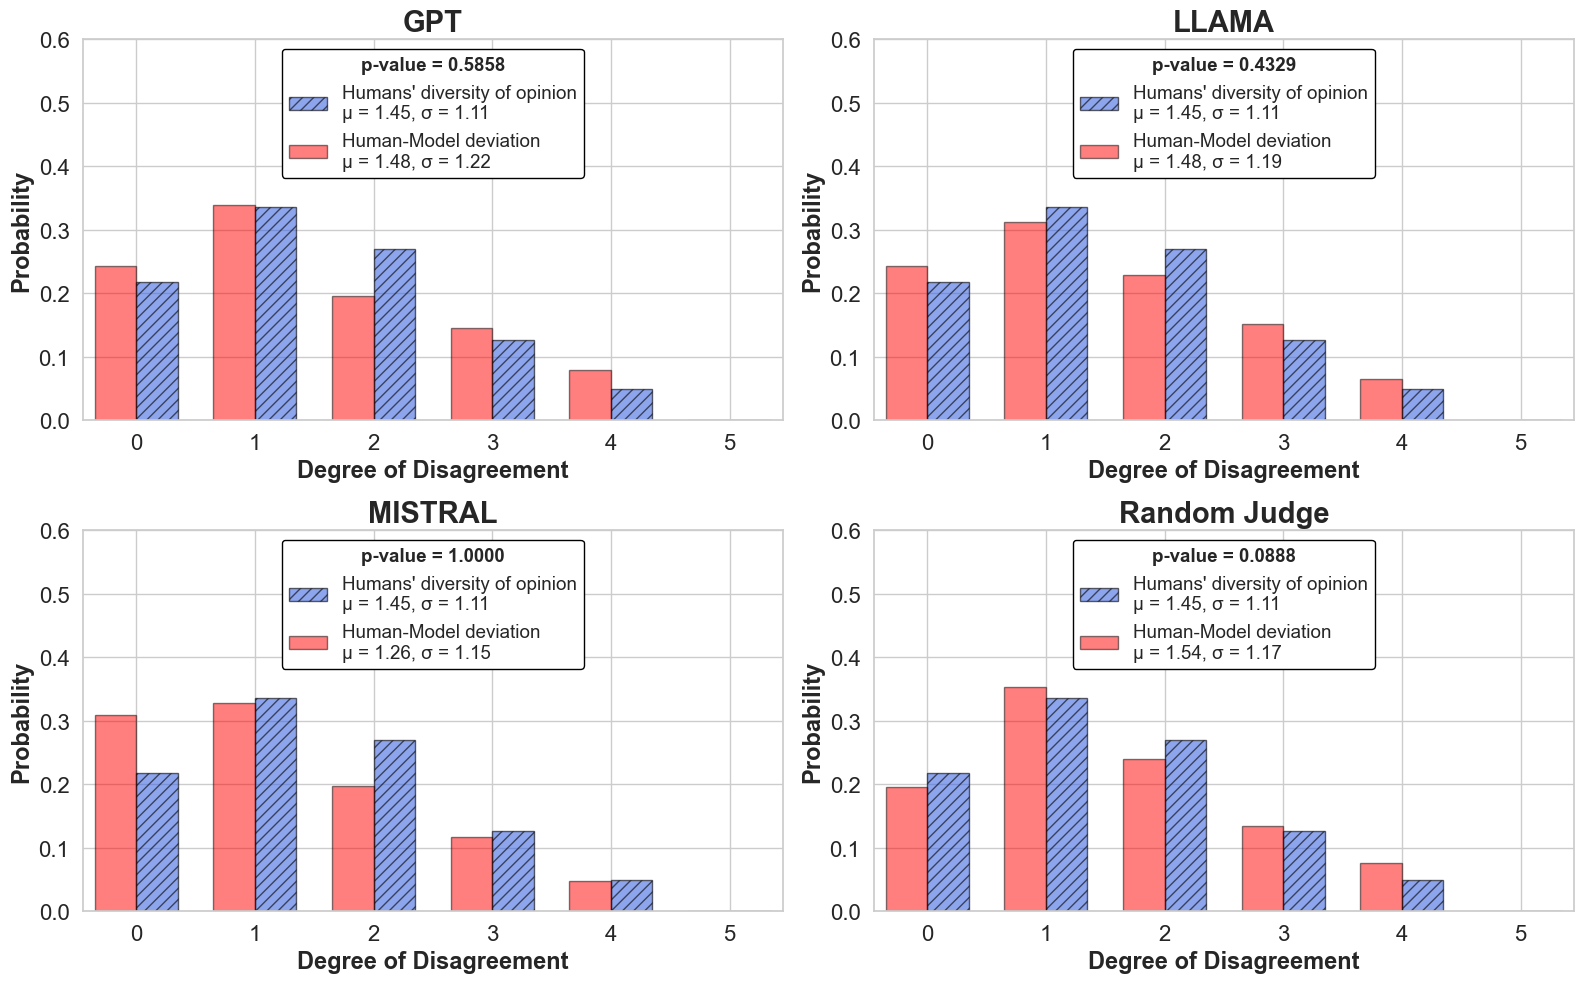

In [58]:
good_enough_fluency.plot_judges_grid(
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.6,
    save_path="../figures/pdf/newsroom_fluency.pdf"
)

### Coherence

✅ Figure saved as PDF → ../figures/pdf/newsroom_coherence.pdf


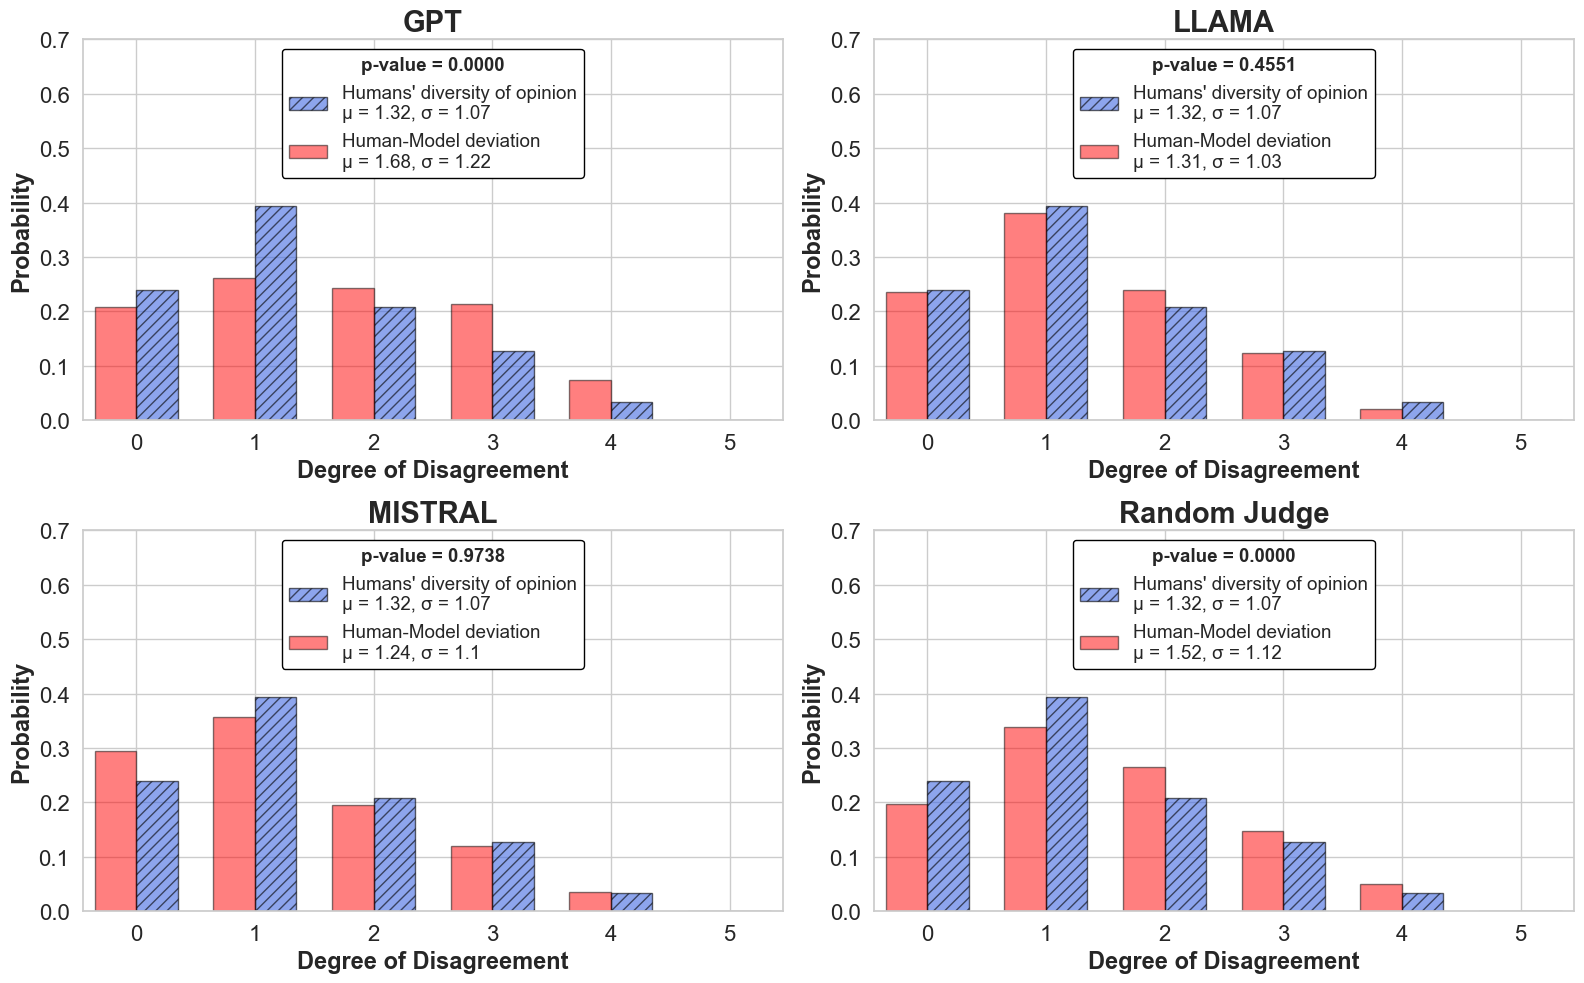

In [59]:
good_enough_coherence.plot_judges_grid(
    bins=np.arange(0, 5 + 2),
    bar_width=0.35,
    y_lim=0.7,
    save_path="../figures/pdf/newsroom_coherence.pdf"
)

In [60]:
xxx

NameError: name 'xxx' is not defined

## Robustness (Monte Carlo)

In [ ]:
# Run robustness visualizations for each metric (all models in one figure)
models = ['GPT', 'LLAMA', 'MISTRAL']

evaluators = {
    'informativeness': good_enough_informativeness,
    'relevance': good_enough_relevance,
    'fluency': good_enough_fluency,
    'coherence': good_enough_coherence
}

for metric_name, evaluator in evaluators.items():
    print(f"=== Running robustness analysis for {metric_name.upper()} ===")
    
    # Build list of LLM columns for this metric
    llm_cols = [f"{model}_{metric_name}_as_a_judge" for model in models]
    
    # Single call → single figure with all 3 LLMs in Panel C
    evaluator.plot_monte_carlo_robustness_multi(
        llm_cols=llm_cols,
        iterations=33_000,
        save_path=f"../svg/monte_carlo_robustness_{metric_name}.svg"
    )

## Human stability analysis

### Informativeness

In [ ]:
good_enough_informativeness.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    max_iterations=500_000,
    min_iterations=20_000,
    save_path="../svg/human_stability_analysis_informativeness.svg",
    parallel=True,
)

### Relevance

In [ ]:
good_enough_relevance.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    max_iterations=500_000,
    min_iterations=20_000,
    save_path="../svg/human_stability_analysis_relevance.svg",
    parallel=True,
)

### Fluency

In [ ]:
good_enough_fluency.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    max_iterations=500_000,
    min_iterations=20_000,
    save_path="../svg/human_stability_analysis_fluency.svg",
    parallel=True,
)

In [ ]:
good_enough_fluency.plot_human_stability_analysis(
    percentages=[
        50, 100, 150, 200, 
        250, 300, 350, 400,
        450, 500, 550, 600,
    ],
    convergence_threshold=0.000005,
    max_iterations=500_000,
    min_iterations=20_000,
    save_path="../svg/human_stability_analysis_fluency.svg",
    parallel=True,
)

### Coherence

In [ ]:
good_enough_coherence.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    max_iterations=500_000,
    min_iterations=20_000,
    save_path="../svg/human_stability_analysis_coherence.svg",
    parallel=True,
)

## LLM stability analysis


In [ ]:
models = ['GPT', 'LLAMA', 'MISTRAL']

### Informativeness

Model: GPT


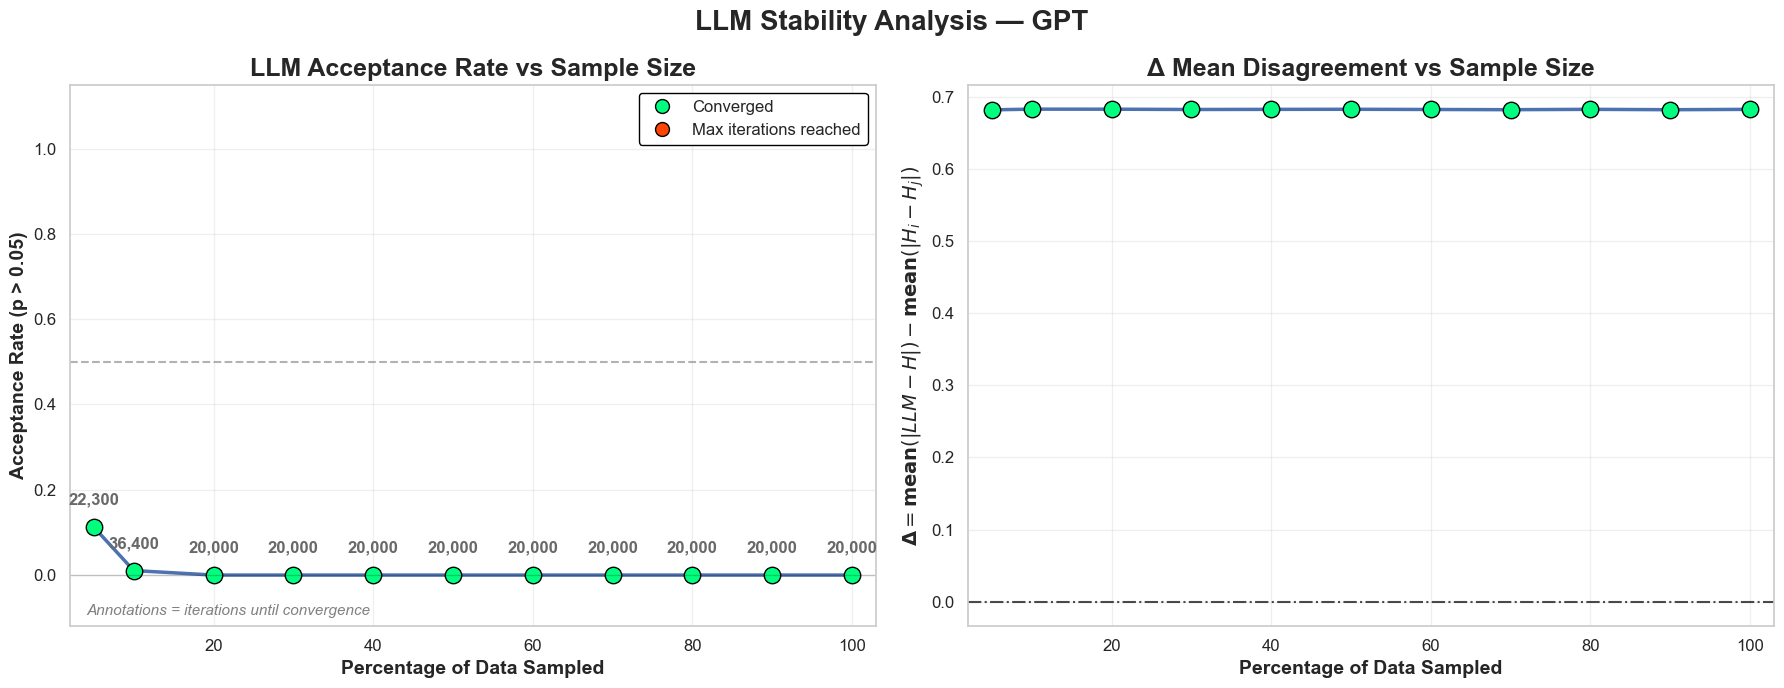

---------------------------------------------------------------------------------------------------
Model: LLAMA


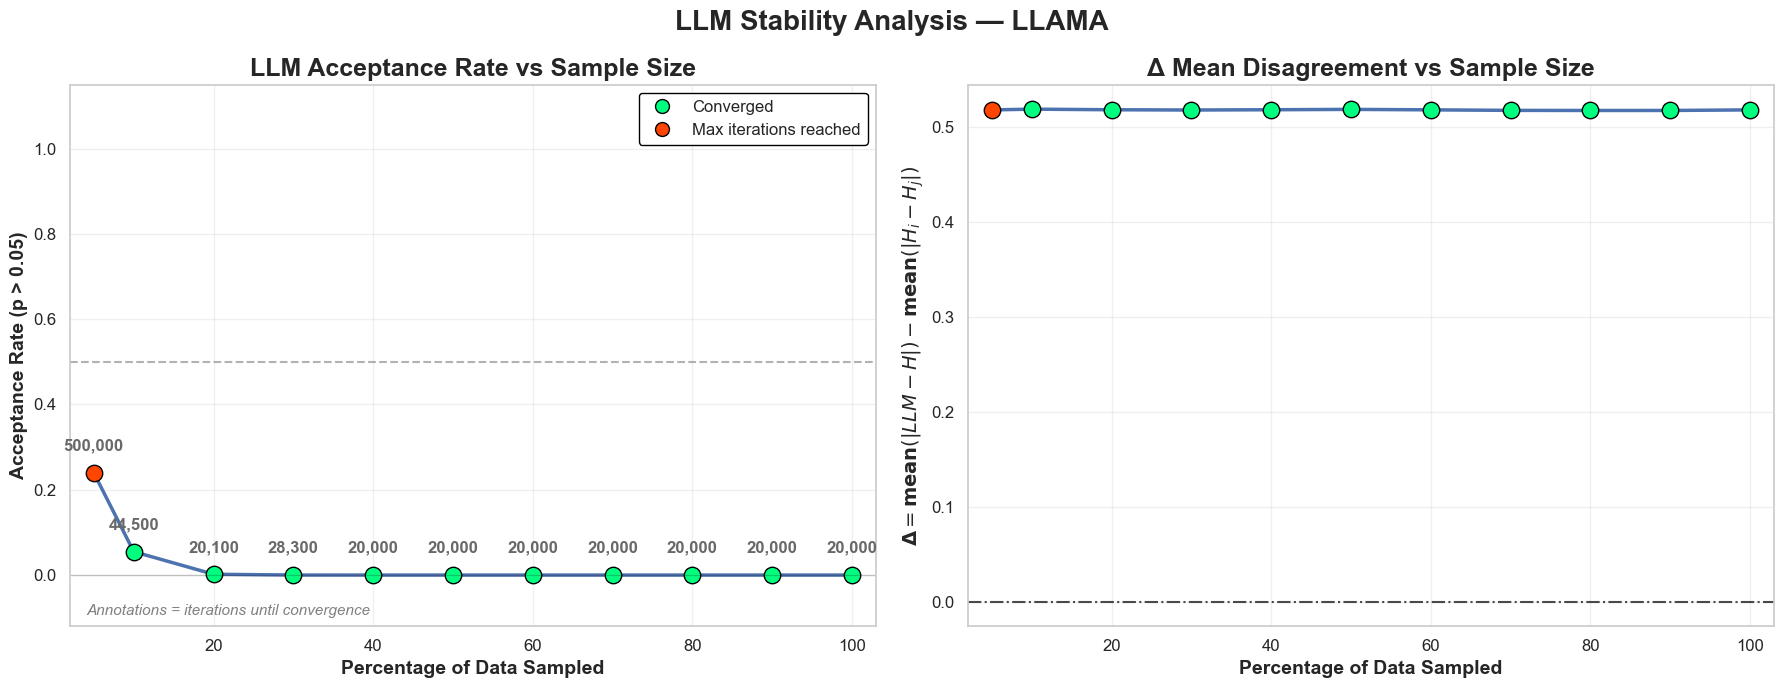

---------------------------------------------------------------------------------------------------
Model: MISTRAL


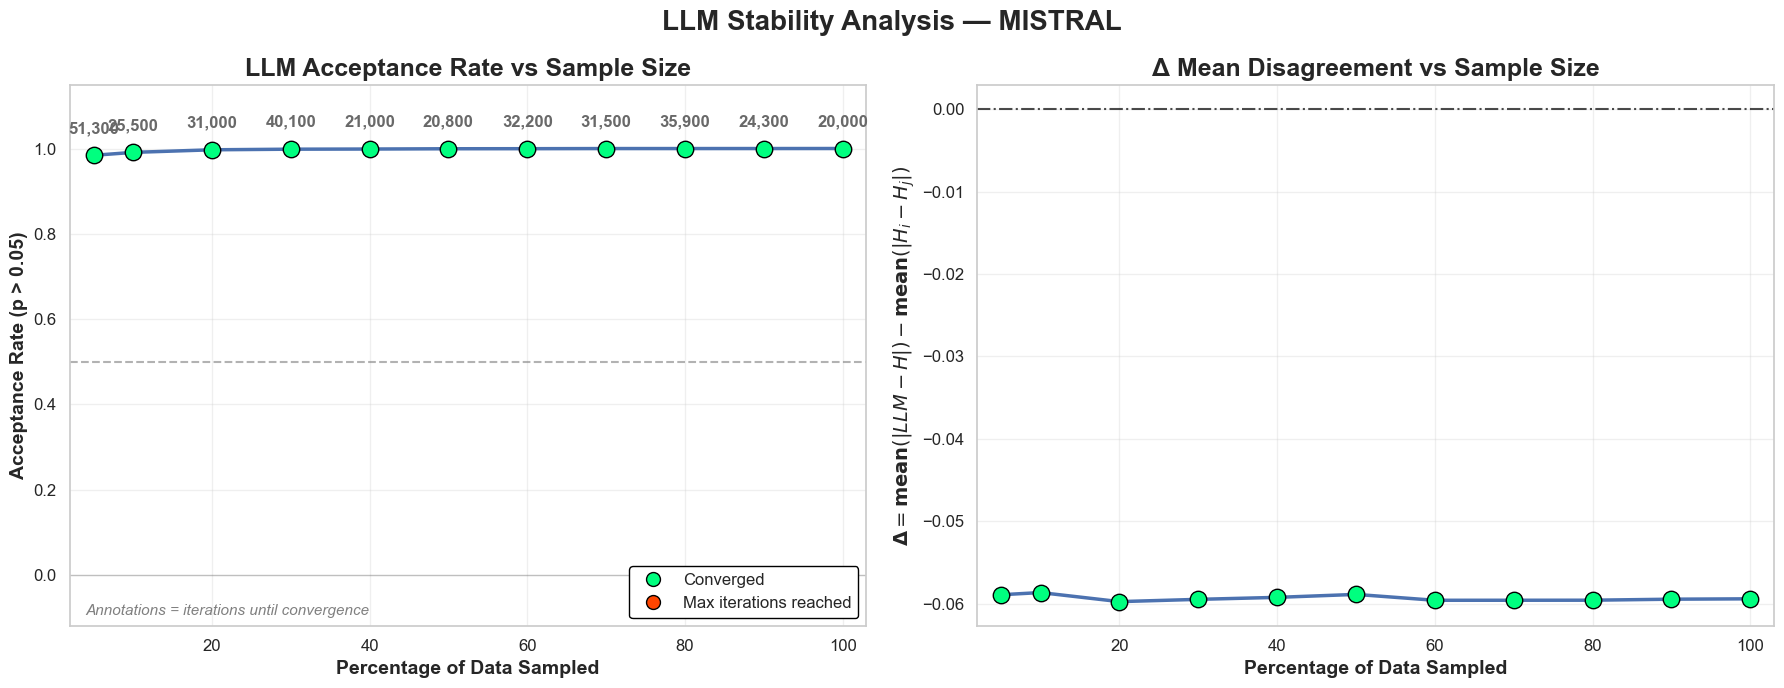

---------------------------------------------------------------------------------------------------


In [ ]:
for model in models:
    print(f"Model: {model}")
    good_enough_informativeness.plot_llm_stability_analysis(
        llm_col=f"{model}_informativeness_as_a_judge",
        convergence_threshold=0.000005,
        min_iterations=20_000,
        max_iterations=500_000,
        save_path="../figures/svg/newsroom_informativeness_llm_stability.svg",
        parallel=True,
    )
    print("-"*99)

### Relevance

Model: GPT


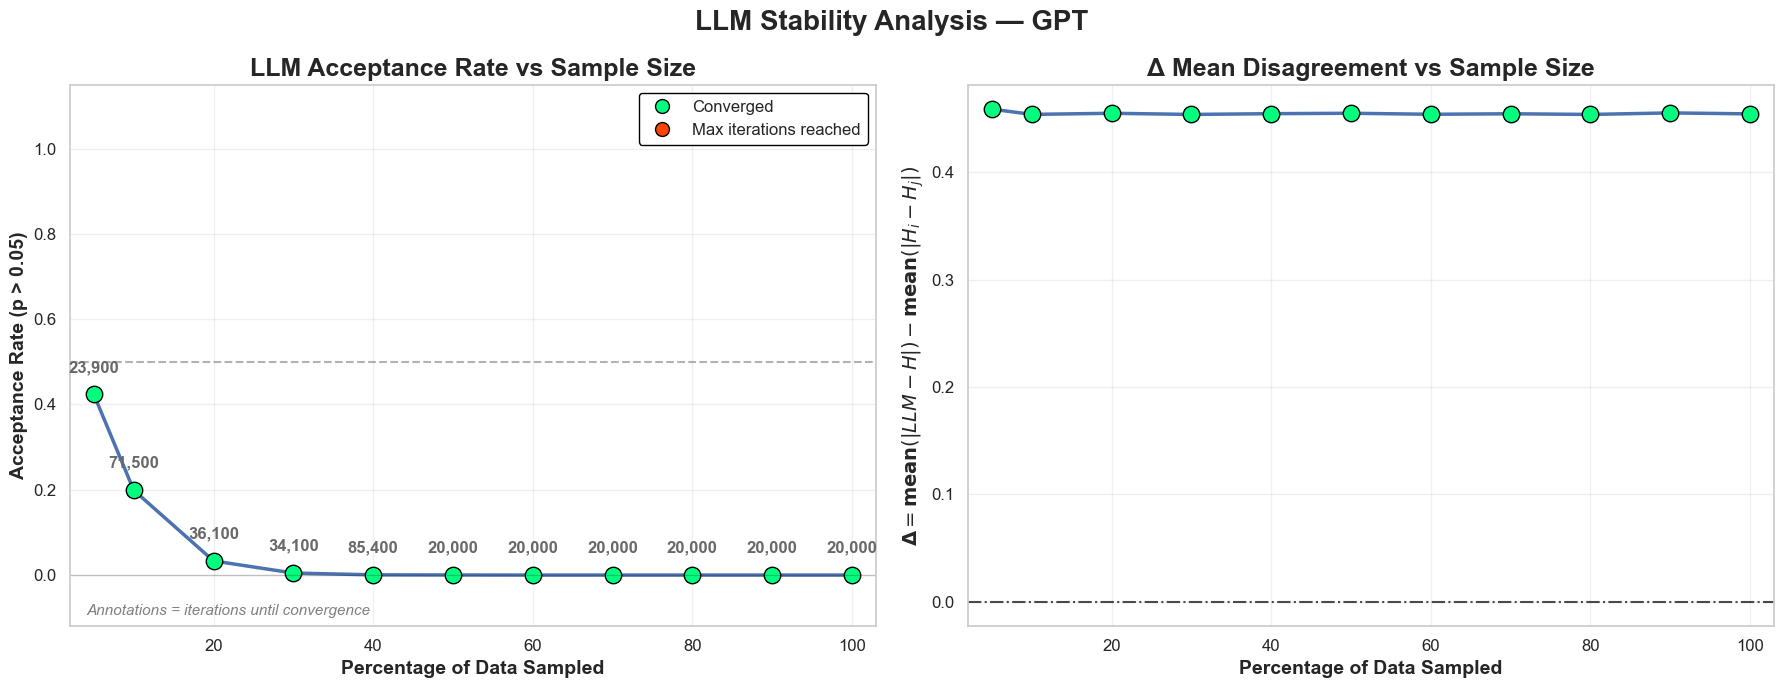

---------------------------------------------------------------------------------------------------
Model: LLAMA


KeyboardInterrupt: 

In [ ]:
for model in models:
    print(f"Model: {model}")
    good_enough_relevance.plot_llm_stability_analysis(
        llm_col=f"{model}_relevance_as_a_judge",
        convergence_threshold=0.000005,
        min_iterations=20_000,
        max_iterations=500_000,
        save_path="../figures/svg/newsroom_relevance_llm_stability.svg",
        parallel=True,
    )
    print("-"*99)

In [ ]:
for model in models:
    print(f"Model: {model}")
    good_enough_fluency.plot_llm_stability_analysis(
        llm_col=f"{model}_fluency_as_a_judge",
        convergence_threshold=0.000005,
        min_iterations=20_000,
        max_iterations=500_000, 
        save_path="../figures/svg/newsroom_fluency_llm_stability.svg",
        parallel=True,
    )
    print("-"*99)

### Coherence

### Fluency

In [ ]:
for model in models:
    print(f"Model: {model}")
    good_enough_coherence.plot_llm_stability_analysis(
        llm_col=f"{model}_coherence_as_a_judge",
        convergence_threshold=0.000005,
        min_iterations=20_000,
        max_iterations=500_000,
        save_path="../figures/svg/newsroom_coherence_llm_stability.svg",
        parallel=True,
    )
    print("-"*99)